In [1]:
!pip install langchain langchain_community
!pip install langchain-groq
from langchain_groq import ChatGroq

In [ ]:
GROQ_API_KEY = "YOUR_GROQ_API_KEY"  # Replace with your actual API key

llm = ChatGroq( 
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY,
)

In [3]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict

In [4]:
class State(TypedDict):
  question:str
  answer:str
  score:int

In [5]:
def answer(state:State):
  student_answer=input(f"""
  Answer for the following question {state['question']}""")
  return {'answer':student_answer}

In [7]:
def evaluate(state: State):
    scoreeee = llm.invoke(
        f"""
            You are an answer evaluation system for {state['question']}.

            Evaluate the quality of the following answer:

            Answer:

            {state['answer']}


            Assign a score from 0 to 100 based on:
            - Accuracy
            - Relevance to the question
            - Completeness
            - Clarity
            - Overall quality

            Scoring guidelines:
            0-39   → Poor
            40-59  → Needs improvement
            60-79  → Good
            80-100 → Excellent

            Return ONLY the integer score between 0 and 100.
            Do not provide any explanation, text, symbols, or punctuation.

            Output example:
            85
        """
    )

    return {'score':int(scoreeee.content)}

In [8]:
def route(state:State):
  if state['score']>=30:
    return "pass"
  else:
    return "fail"

In [9]:
builder=StateGraph(State)

In [10]:
builder.add_node("answer",answer)
builder.add_node("evaluate",evaluate)

In [11]:
builder.add_edge(START,"answer")
builder.add_edge("answer","evaluate")
builder.add_conditional_edges(
    "evaluate",
    route,
    {
        "pass":END,
        "fail":"answer"
    }
)

In [12]:
graph=builder.compile()

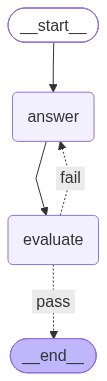

In [13]:
from IPython.display import Image, display

# Render and display the graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
result=graph.invoke(
    {
        "question":"What is the capital of France?",
        "answer":"",
        "score":0
    }
)

print(result)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is Paris', 'score': 100}


In [15]:
result=graph.invoke(
    {
        "question":"What is the capital of France?",
        "answer":"",
        "score":0
    }
)

print(result)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is Paree', 'score': 45}
